# RQ1 — Can UMDA4GI obtain competitive results against state-of-the-art GI algorithms?
**Metric**: `change_perc_validate` — improvement over reference on unseen data (negative = improvement).  
**Algorithms**: FirstImprovement (FI), GeneticProgrammingUniformConcat (GP), RandomSearch, UMDAAlgorithm (UMDA4GI) — all without LLM.  
**Data**: Perf\<Cycles\>, 5-fold CV, budgets {100, 250, 500, 750, 1000}.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

os.makedirs('plots', exist_ok=True)

# READ-ONLY — never write back to results.csv
CSV_PATH = Path('..') / 'results' / 'results.csv'
df_all = pd.read_csv(CSV_PATH)

RQ1_ALGOS = ['FirstImprovement', 'GeneticProgrammingUniformConcat', 'RandomSearch', 'UMDAAlgorithm']

df = df_all[
    (df_all['fitness'] == 'Perf<Cycles>') &
    (df_all['algorithm'].isin(RQ1_ALGOS))
].copy()

# Keep only rows without LLM (pandas reads 'None' from CSV as pd.NA)
df = df[df['llm_model'].isna()]

df['pop_size']             = pd.to_numeric(df['pop_size'],  errors='coerce').fillna(-1).astype(int)
df['max_evals']            = pd.to_numeric(df['max_evals'], errors='coerce').astype(int)
df['change_perc_validate'] = pd.to_numeric(df['change_perc_validate'], errors='coerce')
df['change_perc_train']    = pd.to_numeric(df['change_perc_train'],    errors='coerce')
df['Vt']                   = pd.to_numeric(df['Vt'],                   errors='coerce')
df['Vc']                   = pd.to_numeric(df['Vc'],                   errors='coerce')

print(f'Rows: {len(df)}')
print(f'Algorithms: {sorted(df["algorithm"].unique())}')
print(f'Softwares:  {sorted(df["software"].unique())}')
print(f'max_evals:  {sorted(df["max_evals"].unique())}')

FIXED_COLORS = {
    'FirstImprovement':                cm.tab10(0),
    'GeneticProgrammingUniformConcat': cm.tab10(1),
    'RandomSearch':                    cm.tab10(2),
    'UMDAAlgorithm':                   cm.tab10(3),
    'UMDA4GI':                         cm.tab10(3),
    'UMDA+llama':                      cm.tab10(4),
    'UMDA+qwen':                       cm.tab10(5),
    'LLM-llama':                       cm.tab10(6),
    'LLM-qwen':                        cm.tab10(7),
}


Rows: 400
Algorithms: ['FirstImprovement', 'GeneticProgrammingUniformConcat', 'RandomSearch', 'UMDAAlgorithm']
Softwares:  ['minisat_hack', 'pngOptim', 'sat4j', 'weka']
max_evals:  [np.int64(100), np.int64(250), np.int64(500), np.int64(750), np.int64(1000)]


## 0. Data Quality — Runs with no improvement found

Of the 400 runs in the no-LLM dataset (4 algorithms × 4 softwares × 5 folds × 5 budgets), **11 returned no improvement over the original program** (`patch_length = 0`): the algorithm exhausted its evaluation budget without finding a single variant that both compiled and performed better than the reference. This is expected behaviour in magpie — when no improving variant is found, the original is kept as the best individual and no patch file is written.

These runs are **kept in the dataset** and contribute `change_perc_validate = 0%` (no improvement) to the aggregated medians. Breakdown: **8 Weka runs** (FirstImprovement, various folds and budgets) and **3 OptimPNG runs**.

In [2]:
# Runs where no better variant was found (patch_length == 0)
no_improvement = df[df['patch_length'] == 0][
    ['software', 'algorithm', 'fold', 'max_evals', 'change_perc_validate', 'patch_length']
].sort_values(['software', 'algorithm', 'max_evals', 'fold']).reset_index(drop=True)

print(f'Runs with patch_length == 0: {len(no_improvement)} / {len(df)}')
display(no_improvement)

Runs with patch_length == 0: 11 / 400


,software,algorithm,fold,max_evals,change_perc_validate,patch_length
0,pngOptim,GeneticProgrammingUniformConcat,1,500,0.0,0
1,pngOptim,RandomSearch,5,750,0.0,0
2,pngOptim,RandomSearch,5,1000,0.0,0
3,weka,FirstImprovement,1,1000,0.0,0
4,weka,FirstImprovement,5,1000,0.0,0
5,weka,GeneticProgrammingUniformConcat,3,1000,0.0,0
6,weka,GeneticProgrammingUniformConcat,4,1000,0.0,0
7,weka,GeneticProgrammingUniformConcat,5,1000,0.0,0
8,weka,RandomSearch,3,750,0.0,0
9,weka,RandomSearch,1,1000,0.0,0


In [3]:
group_cols = ['software', 'algorithm', 'pop_size', 'max_evals', 'fitness']

averaged_results = (
    df.groupby(group_cols, as_index=False)
      .agg(
          change_perc_train   =('change_perc_train',    'median'),
          change_perc_validate=('change_perc_validate', 'median'),
          patch_length        =('patch_length',         'mean'),
          search_time_minutes =('search_time_minutes',  'mean'),
          Vt                  =('Vt',                   'mean'),
          Vc                  =('Vc',                   'mean'),
          n_folds             =('fold',                 'count'),
      )
)

# Sanity check: all groups should have exactly 5 folds
bad = averaged_results[averaged_results['n_folds'] != 5]
if bad.empty:
    print('OK — all groups have exactly 5 folds')
else:
    print(f'WARNING — {len(bad)} groups do not have 5 folds:')
    display(bad)

print(f'Aggregated rows: {len(averaged_results)}')
pd.set_option('display.max_rows', None)
display(averaged_results)

OK — all groups have exactly 5 folds
Aggregated rows: 80


,software,algorithm,pop_size,max_evals,fitness,change_perc_train,change_perc_validate,patch_length,search_time_minutes,Vt,Vc,n_folds
0,minisat_hack,FirstImprovement,-1,100,Perf<Cycles>,-78.652,2.044,5.2,14.994293,0.424000,0.542000,5
1,minisat_hack,FirstImprovement,-1,250,Perf<Cycles>,-79.813,25.022,7.2,40.042160,0.478400,0.603200,5
2,minisat_hack,FirstImprovement,-1,500,Perf<Cycles>,-91.941,-86.829,11.4,62.757237,0.502400,0.612400,5
3,minisat_hack,FirstImprovement,-1,750,Perf<Cycles>,-87.615,-6.454,9.8,113.397600,0.467600,0.583400,5
4,minisat_hack,FirstImprovement,-1,1000,Perf<Cycles>,-93.820,-86.402,13.6,123.754293,0.487400,0.600600,5
5,minisat_hack,GeneticProgrammingUniformConcat,50,100,Perf<Cycles>,-5.657,0.402,1.4,13.603793,0.542000,0.618000,5
6,minisat_hack,GeneticProgrammingUniformConcat,50,250,Perf<Cycles>,-63.414,-3.691,1.6,29.117807,0.735200,0.785600,5
7,minisat_hack,GeneticProgrammingUniformConcat,50,500,Perf<Cycles>,-56.327,5.787,4.2,70.534820,0.790800,0.832000,5
8,minisat_hack,GeneticProgrammingUniformConcat,50,750,Perf<Cycles>,-88.047,-84.439,4.8,95.251233,0.813200,0.852200,5
9,minisat_hack,GeneticProgrammingUniformConcat,50,1000,Perf<Cycles>,-87.886,-84.414,6.2,118.660550,0.824800,0.860200,5


## 1. Convergence curves — change_perc_validate vs max_evals (per software)

Softwares found: ['minisat_hack', 'sat4j', 'weka', 'pngOptim']


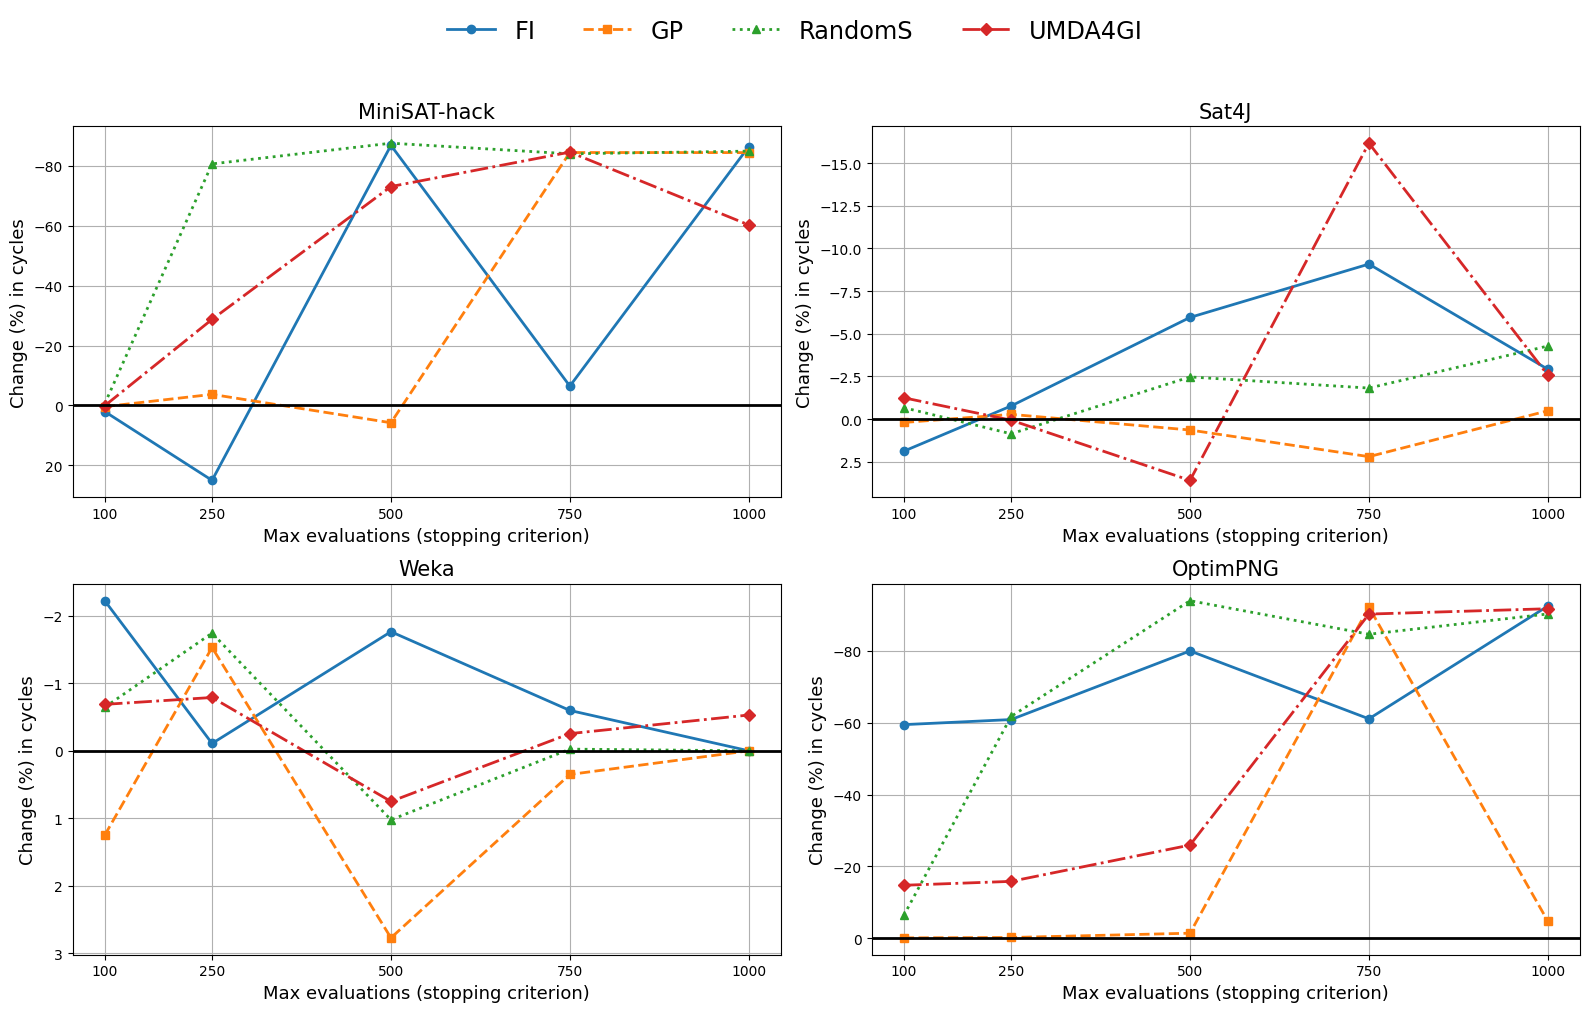

In [4]:
legend_name_map = {
    'FirstImprovement':               'FI',
    'GeneticProgrammingUniformConcat': 'GP',
    'RandomSearch':                   'RandomS',
    'UMDAAlgorithm':                  'UMDA4GI',
}
software_display_map = {
    'minisat_hack': 'MiniSAT-hack',
    'sat4j':        'Sat4J',
    'weka':         'Weka',
    'pngOptim':     'OptimPNG',
}
desired_order = ['minisat_hack', 'sat4j', 'weka', 'pngOptim']

line_styles = ['-', '--', ':', '-.']
markers     = ['o', 's', '^', 'D']

algorithms_all = list(averaged_results['algorithm'].unique())
style_map = {
    alg: {'linestyle': line_styles[i % len(line_styles)],
          'marker':    markers[i % len(markers)],
          'color':     FIXED_COLORS.get(alg, cm.tab10(i % 10)),
          'label':     legend_name_map.get(alg, alg)}
    for i, alg in enumerate(algorithms_all)
}

softwares = [sw for sw in desired_order if sw in averaged_results['software'].values]
print(f'Softwares found: {softwares}')

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False, sharey=False)
axes = axes.flatten()

for ax, software in zip(axes, softwares):
    sw_data = averaged_results[averaged_results['software'] == software]
    for alg in algorithms_all:
        alg_data = sw_data[sw_data['algorithm'] == alg].sort_values('max_evals')
        if alg_data.empty:
            continue
        ax.plot(
            alg_data['max_evals'],
            alg_data['change_perc_validate'],
            label=style_map[alg]['label'],
            linestyle=style_map[alg]['linestyle'],
            marker=style_map[alg]['marker'],
            color=style_map[alg]['color'],
            linewidth=2, markersize=6,
        )
    ax.set_title(software_display_map.get(software, software), fontsize=15)
    ax.set_xlabel('Max evaluations (stopping criterion)', fontsize=13)
    ax.set_ylabel('Change (%) in cycles', fontsize=13)
    ax.invert_yaxis()
    ax.set_xticks(sorted(sw_data['max_evals'].unique()))
    ax.axhline(y=0, color='k', linestyle='-', linewidth=2)
    ax.grid(True)

for i in range(len(softwares), len(axes)):
    axes[i].axis('off')

# Collect legend from first subplot with plotted lines
legend_handles, legend_labels = [], []
for ax in axes[:len(softwares)]:
    h, l = ax.get_legend_handles_labels()
    if h:
        legend_handles, legend_labels = h, l
        break

if legend_handles:
    fig.legend(legend_handles, legend_labels,
               loc='upper center', bbox_to_anchor=(0.5, 1.02),
               ncol=len(legend_labels), fontsize='xx-large', frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('plots/RQ1_ReductionCycles_2x2.svg', format='svg', bbox_inches='tight')
plt.show()


## 2. Ranking — best max_evals per algorithm (by votes across software)

In [5]:
best_idx = averaged_results.groupby(['software', 'algorithm'])['change_perc_validate'].idxmin()
best = averaged_results.loc[best_idx, ['software', 'algorithm', 'max_evals', 'change_perc_validate']].copy()

all_max_evals  = sorted(averaged_results['max_evals'].unique())
all_algorithms = sorted(averaged_results['algorithm'].unique())
votes = best.groupby(['algorithm', 'max_evals']).size().reset_index(name='wins')
full_index = pd.MultiIndex.from_product([all_algorithms, all_max_evals], names=['algorithm', 'max_evals'])
votes = votes.set_index(['algorithm', 'max_evals']).reindex(full_index, fill_value=0).reset_index()
votes['rank'] = votes.groupby('algorithm')['wins'].rank(method='min', ascending=False)

ranking_votes = votes.pivot(index='max_evals', columns='algorithm', values='rank').sort_index()
ranking_votes.columns = [legend_name_map.get(c, c) for c in ranking_votes.columns]

display('Ranking of best max_evals by votes (1 = best):')
display(ranking_votes)

'Ranking of best max_evals by votes (1 = best):'

,FI,GP,RandomS,UMDA4GI
max_evals,,,,
100,1.0,4.0,4.0,4.0
250,5.0,2.0,2.0,2.0
500,1.0,4.0,1.0,4.0
750,1.0,1.0,4.0,1.0
1000,1.0,2.0,2.0,2.0


## 3. Ranking — algorithms per software (averaged across all max_evals)

In [6]:
validate_avg = averaged_results.groupby(['software', 'algorithm'], as_index=False)['change_perc_validate'].mean()
validate_avg['rank'] = validate_avg.groupby('software')['change_perc_validate'].rank(method='min')

alg_ranking = validate_avg.pivot(index='algorithm', columns='software', values='rank').sort_index()
alg_ranking.index   = [legend_name_map.get(i, i) for i in alg_ranking.index]
alg_ranking.columns = [software_display_map.get(c, c) for c in alg_ranking.columns]
alg_ranking['Sum'] = alg_ranking.sum(axis=1)
alg_ranking['Worst'] = alg_ranking.drop(columns='Sum').max(axis=1)
alg_ranking['Top2'] = (alg_ranking.drop(columns=['Sum', 'Worst']) <= 2).sum(axis=1)
alg_ranking = alg_ranking.sort_values(['Sum', 'Worst', 'Top2'], ascending=[True, True, False])

display('Algorithm ranking per software (1 = best avg change_perc_validate):')
display('Tiebreak: Sum → Worst rank (lower better) → Top-2 count (higher better)')
display(alg_ranking)

'Algorithm ranking per software (1 = best avg change_perc_validate):'

'Tiebreak: Sum → Worst rank (lower better) → Top-2 count (higher better)'

,MiniSAT-hack,OptimPNG,Sat4J,Weka,Sum,Worst,Top2
FI,4.0,1.0,1.0,1.0,7.0,4.0,3
UMDA4GI,2.0,3.0,2.0,2.0,9.0,3.0,3
RandomS,1.0,2.0,3.0,3.0,9.0,3.0,2
GP,3.0,4.0,4.0,4.0,15.0,4.0,0


## 4. Search time — search_time_minutes vs max_evals (per software)

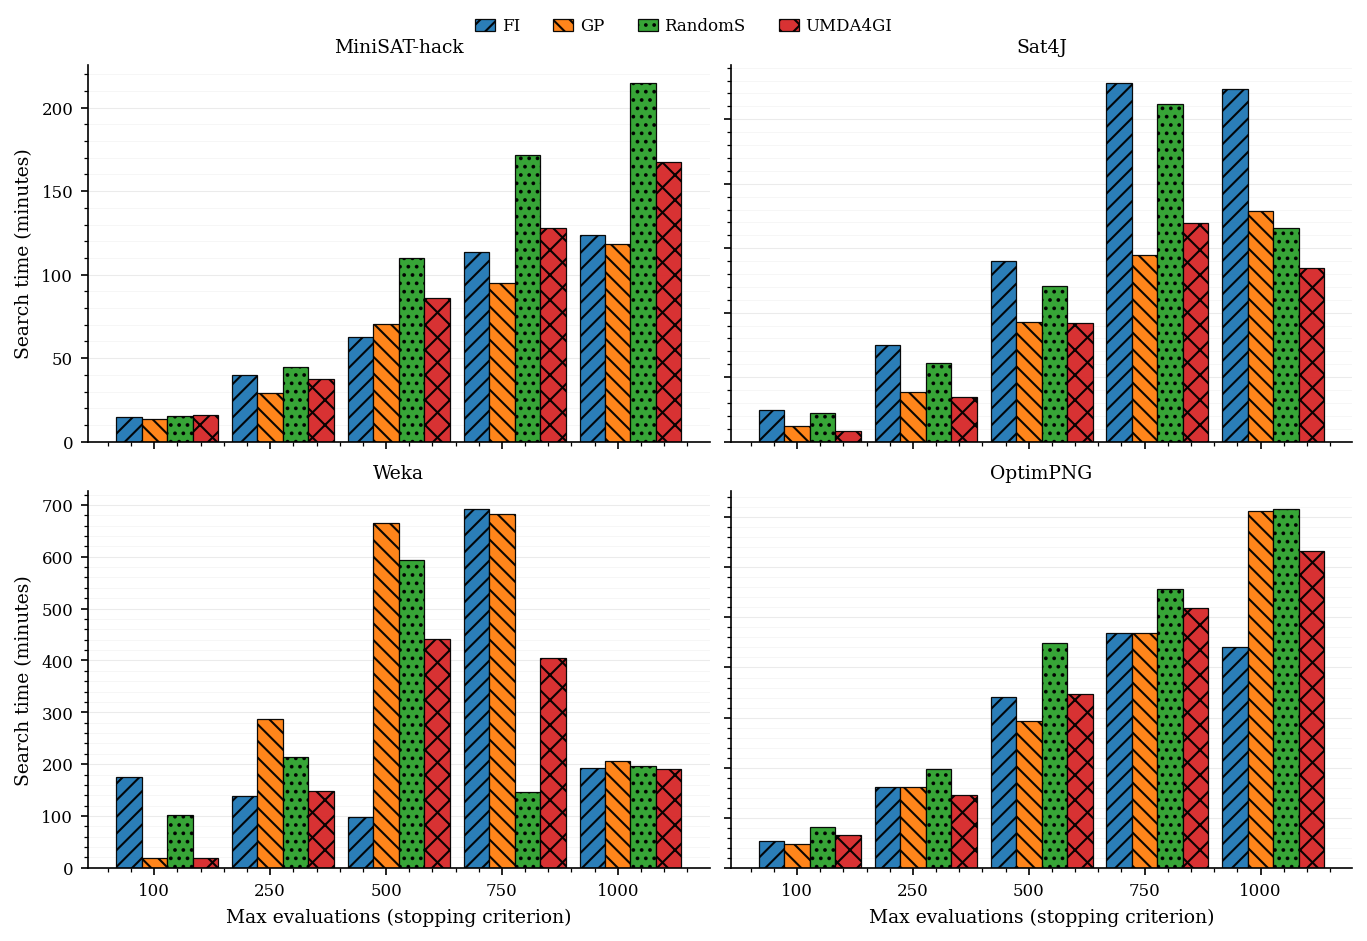

In [7]:
import matplotlib.pyplot as plt
import os

os.makedirs('plots', exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'axes.linewidth': 0.8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'legend.frameon': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.transparent': True,
    'svg.fonttype': 'none',
})

palette = [FIXED_COLORS.get(alg, cm.tab10(i % 10))
           for i, alg in enumerate(algorithms_all)]
hatch_patterns = ['///', '\\\\\\', '...', 'xx', '++', 'oo', '--', '||', '**', '..']

fig, axes = plt.subplots(2, 2, figsize=(9.0, 6.0), constrained_layout=True)
axes = axes.ravel()

handles, labels = None, None

for idx, software in enumerate(softwares):
    ax = axes[idx]
    sw_data = averaged_results[averaged_results['software'] == software].copy()

    x = sorted(sw_data['max_evals'].unique())
    bar_width = 0.22
    positions = range(len(x))
    x_to_pos = {v: j for j, v in enumerate(x)}

    for i, alg in enumerate(algorithms_all):
        alg_data = sw_data[sw_data['algorithm'] == alg].sort_values('max_evals')
        if alg_data.empty:
            continue
        bar_positions = [x_to_pos[ev] + (i * bar_width) for ev in alg_data['max_evals']]
        ax.bar(
            bar_positions,
            alg_data['search_time_minutes'],
            width=bar_width,
            label=legend_name_map.get(alg, alg),
            color=palette[i % len(palette)],
            edgecolor='black',
            linewidth=0.6,
            hatch=hatch_patterns[i % len(hatch_patterns)],
            alpha=0.95,
        )

    ax.set_title(software_display_map.get(software, software))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks([pos + bar_width for pos in positions], x)
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle='-', linewidth=0.5, alpha=0.25)
    ax.minorticks_on()
    ax.grid(axis='y', which='minor', linestyle='-', linewidth=0.35, alpha=0.15)

    row, col = divmod(idx, 2)
    if row != 1:
        ax.tick_params(axis='x', labelbottom=False)
    else:
        ax.set_xlabel('Max evaluations (stopping criterion)', fontsize=9)
    if col != 0:
        ax.tick_params(axis='y', labelleft=False)
    else:
        ax.set_ylabel('Search time (minutes)', fontsize=9)

    if handles is None:
        handles, labels = ax.get_legend_handles_labels()

for j in range(len(softwares), len(axes)):
    axes[j].set_visible(False)

fig.legend(handles, labels,
           loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=len(labels), borderaxespad=0.0,
           handlelength=1.2, handletextpad=0.4,
           labelspacing=0.3, borderpad=0.2)

plt.savefig('plots/RQ1_SearchTime_2x2.svg', format='svg', bbox_inches='tight')
plt.show()

## 5. Ranking — search time

In [8]:
# Ranking of algorithms by mean search_time_minutes per software (1 = fastest)
time_by_sw_alg = averaged_results.groupby(['software', 'algorithm'], as_index=False)['search_time_minutes'].mean()
time_by_sw_alg['rank'] = time_by_sw_alg.groupby('software')['search_time_minutes'].rank(method='min')

rank_alg_time = time_by_sw_alg.pivot(index='algorithm', columns='software', values='rank').sort_index()
rank_alg_time.index   = [legend_name_map.get(i, i) for i in rank_alg_time.index]
rank_alg_time.columns = [software_display_map.get(c, c) for c in rank_alg_time.columns]
rank_alg_time['Sum'] = rank_alg_time.sum(axis=1)
rank_alg_time = rank_alg_time.sort_values('Sum')

display('Algorithm ranking by mean search time per software (1 = fastest):')
display(rank_alg_time)

# Mean search time (minutes) per algorithm and software
time_pivot = time_by_sw_alg.pivot(index='algorithm', columns='software', values='search_time_minutes').sort_index()
time_pivot.index   = [legend_name_map.get(i, i) for i in time_pivot.index]
time_pivot.columns = [software_display_map.get(c, c) for c in time_pivot.columns]
time_pivot['Mean'] = time_pivot.mean(axis=1)

display('Mean search time (minutes) per algorithm and software:')
display(time_pivot.round(2))

# Ranking of max_evals by mean search_time_minutes per algorithm (1 = fastest)
time_by_alg_budget = averaged_results.groupby(['algorithm', 'max_evals'], as_index=False)['search_time_minutes'].mean()
time_by_alg_budget['rank'] = time_by_alg_budget.groupby('algorithm')['search_time_minutes'].rank(method='min')

rank_budget_time = time_by_alg_budget.pivot(index='max_evals', columns='algorithm', values='rank').sort_index()
rank_budget_time.columns = [legend_name_map.get(c, c) for c in rank_budget_time.columns]

display('max_evals ranking by mean search time per algorithm (1 = fastest):')
display(rank_budget_time)

'Algorithm ranking by mean search time per software (1 = fastest):'

,MiniSAT-hack,OptimPNG,Sat4J,Weka,Sum
UMDA4GI,3.0,3.0,1.0,1.0,8.0
GP,1.0,2.0,2.0,4.0,9.0
FI,2.0,1.0,4.0,3.0,10.0
RandomS,4.0,4.0,3.0,2.0,13.0


'Mean search time (minutes) per algorithm and software:'

,MiniSAT-hack,OptimPNG,Sat4J,Weka,Mean
FI,70.99,292.94,316.63,259.16,234.93
GP,65.43,336.82,186.89,371.97,240.28
RandomS,111.36,400.29,252.80,250.52,253.74
UMDA4GI,87.04,342.26,175.76,240.24,211.33


'max_evals ranking by mean search time per algorithm (1 = fastest):'

,FI,GP,RandomS,UMDA4GI
max_evals,,,,
100,1.0,1.0,1.0,1.0
250,2.0,2.0,2.0,2.0
500,3.0,3.0,3.0,3.0
750,5.0,5.0,4.0,5.0
1000,4.0,4.0,5.0,4.0


## RQ1 — Conclusions

### Direct answer

**Yes. UMDA4GI achieves competitive results** against state-of-the-art GI algorithms. Using median aggregation (robust to atypical folds), UMDA4GI ties with RandomSearch (Sum=9) and is **the most consistent algorithm**: rank 2 in 3 out of 4 software targets. FirstImprovement leads globally (Sum=7), winning in 3 out of 4 softwares.

### Global ranking (sum of ranks per software, 1 = best)

**Tiebreaker: when two algorithms have the same Sum, ties are broken first by the worst individual rank (lower = more robust, no software where it performs poorly); if still tied, by the number of softwares in which they reach rank ≤ 2 (higher = more consistent).**

| Algorithm | MiniSAT-hack | OptimPNG | Sat4J | Weka | **Sum** | Worst | Top-2 |
|-----------|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **FI** | 4 | **1** | **1** | **1** | **7** | 4 | 3 |
| **UMDA4GI** | 2 | 3 | 2 | 2 | **9** | 3 | **3** |
| **RandomS** | **1** | 2 | 3 | 3 | **9** | 3 | 2 |
| GP | 3 | 4 | 4 | 4 | **15** | 4 | 0 |

**UMDA4GI and RandomSearch tie on Sum (9) and worst rank (3). The tiebreaker is the number of softwares with rank ≤ 2: UMDA4GI reaches rank ≤ 2 in 3 softwares (MiniSAT-hack, Sat4J, Weka) vs. 2 for RandomSearch (MiniSAT-hack, OptimPNG), placing UMDA4GI 2nd overall.**

### Findings per software

**MiniSAT-hack** — substantial improvements (median up to −88%):
- All algorithms improve significantly.
- RandomSearch is best (rank 1, mean −67.5%): high patch density favours stochastic exploration.
- UMDA4GI is 2nd (−49.3%): the probabilistic distribution guides search well, especially at mid-to-high budgets (−73% at 500, −85% at 750).
- GP is 3rd (−33.3%) and FI 4th (−30.5%). FI is highly variable: excellent at high budgets (−87% at 500/1000) but worsens at low budgets (+2% at 100, +25% at 250).

**OptimPNG** — significant improvements (median up to −94%):
- FI is best (rank 1, mean −70.8%): consistent across all budgets (−59% to −92%).
- RandomSearch is 2nd (−67.4%): very strong at mid-to-high budgets (−94% at 500, −85% at 750, −90% at 1000).
- UMDA4GI is 3rd (−47.7%): progressive improvement with budget (−15% at 100/250, −26% at 500, −90% at 750, −92% at 1000).
- GP is 4th (−19.7%): only competitive at budget=750 (−92%) but poor otherwise.

**Sat4J** — moderate improvements:
- FI is best (rank 1, mean −3.4%): clear improvement at medium budgets (−6% at 500, −9% at 750).
- UMDA4GI close behind in 2nd (−3.3%): peaks at 750 (−16%) but inconsistent at other budgets.
- RandomSearch is 3rd (−1.7%), GP 4th (+0.5%).

**Weka** — small improvements (<2.3%):
- FI wins (rank 1, −0.9%). UMDA4GI and RandomSearch tie 2nd–3rd (both −0.3%).
- Mature, highly optimised ML classification software with little room for GI via text-level edits.

### Budget effect

In MiniSAT-hack and OptimPNG, improvement tends to grow with budget for all algorithms. In Sat4J, the same trend holds but with higher variability. In Weka, the relationship is noisy and non-monotonic.

### Search time

| Algorithm | MiniSAT-hack | OptimPNG | Sat4J | Weka | **Sum** |
|-----------|:---:|:---:|:---:|:---:|:---:|
| **UMDA4GI** | 3 | 3 | **1** | **1** | **8** |
| GP | **1** | 2 | 2 | 4 | 9 |
| FI | 2 | **1** | 4 | 3 | 10 |
| RandomS | 4 | 4 | 3 | 2 | 13 |

UMDA4GI is the fastest overall (Sum=8, mean 211.3 min), followed by GP (Sum=9, mean 240.3 min) and FI (Sum=10, mean 234.9 min), with RandomSearch the slowest (Sum=13, mean 253.7 min). UMDA4GI is fastest in Sat4J and Weka; GP in MiniSAT-hack; FI in OptimPNG.

### Implications for the paper

- **FI achieves the best overall improvement** (Sum=7): wins in 3 out of 4 softwares. Its greedy local search is simple and effective.
- **UMDA4GI is the most consistent in improvement** (never worse than rank 3, rank 2 in 3 softwares) **and the fastest** (Sum=8 in search time). Competitive against state-of-the-art GI.
- **RandomSearch** performs well where useful patches are dense (MiniSAT-hack rank 1, OptimPNG rank 2) but is less effective on harder targets and is the slowest overall (Sum=13).
- **GP finishes last in 3 out of 4 softwares** — its crossover operator provides no advantage in these domains.
- **OptimPNG** shows real, substantial improvements (up to −94%) following the compile pipeline and validation test fixes.

### Limitations

- Aggregation by **median**: robust to atypical folds (COMPILE_TIMEOUT, train=0) and to the 11 runs with no improvement found (see Section 0), but may hide fold-level variability.
- The ranking in Weka is sensitive to noise due to the small magnitude of differences.